In [1]:
import operator
from typing import Annotated, List, TypedDict, Dict, Any
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage

# Pure Python/Windows-friendly libraries
from rdkit import Chem
from rdkit.Chem import Descriptors, QED, AllChem, rdShapeHelpers
import os 
from dotenv import load_dotenv
from langchain_ollama import ChatOllama


In [2]:
load_dotenv()

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["LANGCHAIN_PROJECT"] = os.getenv("LANGSMITH_PROJECT")

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

llm = ChatGroq(model="openai/gpt-oss-120b")


In [ ]:
'''llm=ChatOllama(model="medgemma:4b")
llm.invoke("help me in the medicen")'''

ConnectError: [WinError 10061] No connection could be made because the target machine actively refused it

In [3]:
class DrugDesignState(TypedDict):
    target_info: str
    current_smiles: List[str]
    eval_results: Annotated[List[Dict[str, Any]], operator.add]
    best_candidates: Annotated[List[Dict[str, Any]], operator.add]
    iteration: int
    feedback: str
    history_log: Annotated[List[str], operator.add]



In [4]:
REF_SMILES = "c1ccccc1NC(=O)c2cnc(nc2)N" # Example: Imatinib core
ref_mol = Chem.AddHs(Chem.MolFromSmiles(REF_SMILES))
AllChem.EmbedMolecule(ref_mol, randomSeed=42)
AllChem.MMFFOptimizeMolecule(ref_mol)

0

In [5]:
def ingest_target(state: DrugDesignState):
    return {"iteration": 0, "history_log": ["[Iteration 0] Ingested target specification."]}

def generate_molecules(state: DrugDesignState):
    iter_num = state["iteration"] + 1
    prompt = f"""
    You are an expert medicinal chemist designing de novo small molecules.
    Target Specification: {state['target_info']}
    Previous Cycle Feedback: {state.get('feedback', 'Initial generation cycle.')}

    Rules:
    - Output ONLY one valid SMILES string.
    - No markdown formatting, backticks, or explanatory text.
    """
    response = llm.invoke([HumanMessage(content=prompt)])
    smiles = response.content.strip().replace("`", "").replace("smiles", "").strip()

    return {
        "current_smiles": [smiles],
        "iteration": iter_num,
        "eval_results": [],
        "history_log": [f"[Iteration {iter_num}] Generated Candidate SMILES: {smiles}"]
    }

def eval_rdkit(state: DrugDesignState):
    """Tool Grounding: RDKit calculates real QED, LogP, and Molecular Weight."""
    results = []
    for smiles in state["current_smiles"]:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            results.append({
                "smiles": smiles, "source": "RDKit", "valid": False,
                "qed": 0.0, "logp": 0.0, "mw": 0.0
            })
            continue

        results.append({
            "smiles": smiles,
            "source": "RDKit",
            "valid": True,
            "qed": round(float(QED.qed(mol)), 3),
            "logp": round(float(Descriptors.MolLogP(mol)), 2),
            "mw": round(float(Descriptors.MolWt(mol)), 2)
        })
    return {"eval_results": results}

def eval_docking(state: DrugDesignState):
    """Windows-Friendly 3D Shape Evaluator (Replaces Vina)"""
    results = []
    for smiles in state["current_smiles"]:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            results.append({"smiles": smiles, "source": "Docking", "score": 0.0})
            continue
            
        try:
            mol_3d = Chem.AddHs(mol)
            AllChem.EmbedMolecule(mol_3d, randomSeed=42)
            AllChem.MMFFOptimizeMolecule(mol_3d)
            
            # Shape similarity: 1.0 is a perfect 3D fit, 0.0 is complete mismatch
            shape_sim = 1.0 - rdShapeHelpers.ShapeTanimotoDist(ref_mol, mol_3d)
            
            # Convert to a simulated binding score scale (e.g. -10 to 0)
            surrogate_binding_energy = round(-10.0 * shape_sim, 2)
            
            results.append({
                "smiles": smiles, 
                "source": "Docking", 
                "score": surrogate_binding_energy
            })
        except Exception:
            results.append({"smiles": smiles, "source": "Docking", "score": -3.0})
            
    return {"eval_results": results}

def aggregate_and_score(state: DrugDesignState):
    smiles_map = {}
    for res in state["eval_results"]:
        s = res["smiles"]
        if s not in smiles_map:
            smiles_map[s] = {"smiles": s, "total_score": 0.0, "valid": False, "qed": 0.0, "logp": 0.0, "mw": 0.0, "docking": 0.0}

        if res["source"] == "RDKit":
            smiles_map[s]["valid"] = res["valid"]
            smiles_map[s]["qed"] = res["qed"]
            smiles_map[s]["logp"] = res["logp"]
            smiles_map[s]["mw"] = res["mw"]
            smiles_map[s]["total_score"] += (res["qed"] * 20.0) if res["valid"] else -100.0

        elif res["source"] == "Docking":
            smiles_map[s]["docking"] = res["score"]
            smiles_map[s]["total_score"] += abs(res["score"]) * 2.0

    return {"best_candidates": list(smiles_map.values())}

def critic(state: DrugDesignState):
    latest = state["best_candidates"][-1] if state["best_candidates"] else None
    if not latest or not latest.get("valid", False):
        fb = "Previous candidate was chemically invalid. Produce a clean, valid SMILES core."
        return {"feedback": fb, "history_log": [f"[Critic Feedback] {fb}"]}

    prompt = f"""
    Current Candidate: {latest['smiles']}
    Molecular Weight: {latest['mw']} Da
    LogP: {latest['logp']}
    QED Score: {latest['qed']}
    Shape Match Score: {latest['docking']} (Target: < -7.5)

    Give a concise 1-2 sentence medicinal chemistry critique explaining which chemical 
    group to modify to optimize the 3D shape and drug-likeness.
    """
    response = llm.invoke([HumanMessage(content=prompt)])
    fb = response.content.strip()
    return {"feedback": fb, "history_log": [f"[Critic Feedback] {fb}"]}

def route_next_step(state: DrugDesignState) -> str:
    if state["iteration"] >= 4:
        return "finalize"
    if state["best_candidates"]:
        top = state["best_candidates"][-1]
        if top.get("valid") and top.get("qed", 0) >= 0.70 and top.get("docking", 0) <= -7.5:
            return "finalize"
    return "generate"

def finalize(state: DrugDesignState):
    return state

In [6]:
builder = StateGraph(DrugDesignState)
builder.add_node("ingest", ingest_target)
builder.add_node("generate", generate_molecules)
builder.add_node("eval_rdkit", eval_rdkit)
builder.add_node("eval_docking", eval_docking)
builder.add_node("aggregate", aggregate_and_score)
builder.add_node("critic", critic)
builder.add_node("finalize", finalize)

builder.add_edge(START, "ingest")
builder.add_edge("ingest", "generate")
builder.add_edge("generate", "eval_rdkit")
builder.add_edge("generate", "eval_docking")
builder.add_edge("eval_rdkit", "aggregate")
builder.add_edge("eval_docking", "aggregate")
builder.add_edge("aggregate", "critic")
builder.add_conditional_edges("critic", route_next_step, {"generate": "generate", "finalize": "finalize"})
builder.add_edge("finalize", END)

checkpointer = MemorySaver()
drug_agent = builder.compile(checkpointer=checkpointer)

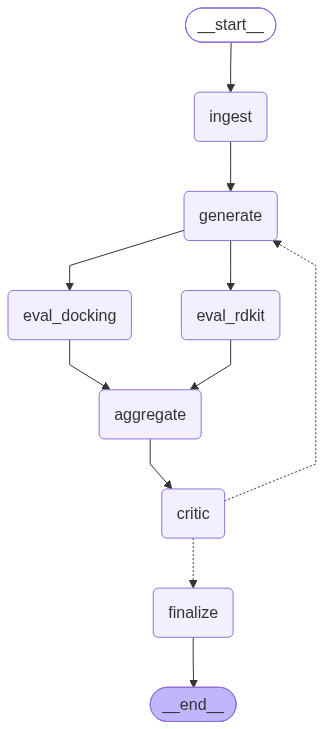

In [13]:
drug_agent

In [7]:


initial_input = {
    "target_info": (
        "Target: MYC Transcription Factor (c-Myc).\n"
        "Disease context: High-grade aggressive cancers (e.g., Pancreatic).\n"
        "Challenge: Target is intrinsically disordered with no traditional binding pockets. It cannot be blocked conventionally.\n"
        "Design Strategy: Design a 'Molecular Glue' degrader. The molecule must have two ends:\n"
        "  1. A side that weakly binds to the flat surface of MYC.\n"
        "  2. A side that binds to Cereblon (an E3 ubiquitin ligase).\n"
        "Design Objectives: High membrane permeability, molecular weight under 800 Da, "
        "must trigger the degradation of MYC rather than simple inhibition."
    ),
    "current_smiles": [],
    "eval_results": [],
    "best_candidates": [],
    "iteration": 0,
    "feedback": "Start by generating heterobifunctional molecules (molecules with two distinct binding heads connected by a flexible chemical linker)."
}


config = {"configurable": {"thread_id": "test_run_01"}}
    
    # Run the graph
print("Starting agent...")
result = drug_agent.invoke(initial_input, config=config)




Starting agent...


[14:04:05] Explicit valence for atom # 12 O, 3, is greater than permitted
[14:04:05] Explicit valence for atom # 12 O, 3, is greater than permitted


In [8]:
print("\n--- FINAL RESULT ---")
print(result["best_candidates"][-1])



--- FINAL RESULT ---
{'smiles': 'O=C1NC(=O)C2=CC=CC=C2C1=OC(=O)N2CCC(=O)N(C2=O)C(=O)NC3CCCCC3', 'total_score': -100.0, 'valid': False, 'qed': 0.0, 'logp': 0.0, 'mw': 0.0, 'docking': 0.0}


In [ ]:
result.pretty

In [18]:
import pprint

# Create a pretty printer object
pp = pprint.PrettyPrinter(indent=4)

# Run the graph
final_state = drug_agent.invoke(initial_input, config=config)

# Pretty print the final state dictionary
print("\n=== FINAL AGENT STATE ===")
pp.pprint(final_state)

[09:20:39] SMILES Parse Error: syntax error while parsing: CC(C)C1=NC(=O)N(C(=O)N1C2=CC=CC=C2)C(=O)CH2CH2OCH2CH2NHCH2c3ccc(cc3)C
[09:20:39] SMILES Parse Error: syntax error while parsing: CC(C)C1=NC(=O)N(C(=O)N1C2=CC=CC=C2)C(=O)CH2CH2OCH2CH2NHCH2c3ccc(cc3)C
[09:20:39] SMILES Parse Error: check for mistakes around position 42:
[09:20:39] N1C2=CC=CC=C2)C(=O)CH2CH2OCH2CH2NHCH2c3cc
[09:20:39] ~~~~~~~~~~~~~~~~~~~~^
[09:20:39] SMILES Parse Error: Failed parsing SMILES 'CC(C)C1=NC(=O)N(C(=O)N1C2=CC=CC=C2)C(=O)CH2CH2OCH2CH2NHCH2c3ccc(cc3)C' for input: 'CC(C)C1=NC(=O)N(C(=O)N1C2=CC=CC=C2)C(=O)CH2CH2OCH2CH2NHCH2c3ccc(cc3)C'
[09:20:39] SMILES Parse Error: check for mistakes around position 42:
[09:20:39] N1C2=CC=CC=C2)C(=O)CH2CH2OCH2CH2NHCH2c3cc
[09:20:39] ~~~~~~~~~~~~~~~~~~~~^
[09:20:39] SMILES Parse Error: Failed parsing SMILES 'CC(C)C1=NC(=O)N(C(=O)N1C2=CC=CC=C2)C(=O)CH2CH2OCH2CH2NHCH2c3ccc(cc3)C' for input: 'CC(C)C1=NC(=O)N(C(=O)N1C2=CC=CC=C2)C(=O)CH2CH2OCH2CH2NHCH2c3ccc(cc3)C'
[09:20:50] Can


=== FINAL AGENT STATE ===
{   'best_candidates': [   {   'docking': 0.0,
                               'logp': 0.0,
                               'mw': 0.0,
                               'qed': 0.0,
                               'smiles': 'CC(C)(C)C(=O)N1CCC(=O)NC1=OCCOCCOCCOc1ccc2c(c1)cccc2',
                               'total_score': -100.0,
                               'valid': False},
                           {   'docking': 0.0,
                               'logp': 0.0,
                               'mw': 0.0,
                               'qed': 0.0,
                               'smiles': 'CC(C)(C)C(=O)N1CCC(=O)NC1=OCCOCCOCCOc1ccc2c(c1)cccc2',
                               'total_score': -100.0,
                               'valid': False},
                           {   'docking': -3.16,
                               'logp': 2.54,
                               'mw': 476.54,
                               'qed': 0.595,
                               'smiles'